# Importing Libraries and Data

In [1]:
import numpy as np
import pandas as pd 
import os
import warnings
warnings.filterwarnings('ignore') 

# Transactions Data Analysis


In [2]:
df=pd.read_csv(r"D:\Iyyappa\Analytics Projects\transactions_data.csv")
df

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,7475327,2010-01-01 00:01:00,1556,2972,$-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,NaN
1,7475328,2010-01-01 00:02:00,561,4575,$14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,NaN
2,7475329,2010-01-01 00:02:00,1129,102,$80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,NaN
3,7475331,2010-01-01 00:05:00,430,2860,$200.00,Swipe Transaction,27092,Crown Point,IN,46307.0,4829,NaN
4,7475332,2010-01-01 00:06:00,848,3915,$46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
13305910,23761868,2019-10-31 23:56:00,1718,2379,$1.11,Chip Transaction,86438,West Covina,CA,91792.0,5499,NaN
13305911,23761869,2019-10-31 23:56:00,1766,2066,$12.80,Online Transaction,39261,ONLINE,NaN,NaN,5815,NaN
13305912,23761870,2019-10-31 23:57:00,199,1031,$40.44,Swipe Transaction,2925,Allen,TX,75002.0,4900,NaN
13305913,23761873,2019-10-31 23:58:00,1986,5443,$4.00,Chip Transaction,46284,Daly City,CA,94014.0,5411,NaN


In [3]:
import json

with open(r"D:\Users\Iyyappa\Downloads\mcc_codes.json") as f:
    data = json.load(f)

type(data), list(data.keys()) if isinstance(data, dict) else None
import pandas as pd

df2 = pd.DataFrame(
    list(data.items()),
    columns=['Code', 'Industry']
)

df2.head()


,Code,Industry
0,5812,Eating Places and Restaurants
1,5541,Service Stations
2,7996,"Amusement Parks, Carnivals, Circuses"
3,5411,"Grocery Stores, Supermarkets"
4,4784,Tolls and Bridge Fees


In [4]:
df.tail()


,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
13305910,23761868,2019-10-31 23:56:00,1718,2379,$1.11,Chip Transaction,86438,West Covina,CA,91792.0,5499,NaN
13305911,23761869,2019-10-31 23:56:00,1766,2066,$12.80,Online Transaction,39261,ONLINE,NaN,NaN,5815,NaN
13305912,23761870,2019-10-31 23:57:00,199,1031,$40.44,Swipe Transaction,2925,Allen,TX,75002.0,4900,NaN
13305913,23761873,2019-10-31 23:58:00,1986,5443,$4.00,Chip Transaction,46284,Daly City,CA,94014.0,5411,NaN
13305914,23761874,2019-10-31 23:59:00,489,5697,$12.88,Chip Transaction,24658,Greenbrier,TN,37073.0,5921,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13305915 entries, 0 to 13305914
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          -----  
 0   id              int64  
 1   date            object 
 2   client_id       int64  
 3   card_id         int64  
 4   amount          object 
 5   use_chip        object 
 6   merchant_id     int64  
 7   merchant_city   object 
 8   merchant_state  object 
 9   zip             float64
 10  mcc             int64  
 11  errors          object 
dtypes: float64(1), int64(5), object(6)
memory usage: 1.2+ GB


In [6]:
df.isna().sum()

id                       0
date                     0
client_id                0
card_id                  0
amount                   0
use_chip                 0
merchant_id              0
merchant_city            0
merchant_state     1563700
zip                1652706
mcc                      0
errors            13094522
dtype: int64

In [7]:
df['date'] = pd.to_datetime(df['date'])
df['amount'] = (
    df['amount']
    .str.replace('[\$,]', '', regex=True)
)

df['amount'] = pd.to_numeric(df['amount'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13305915 entries, 0 to 13305914
Data columns (total 12 columns):
 #   Column          Dtype         
---  ------          -----         
 0   id              int64         
 1   date            datetime64[ns]
 2   client_id       int64         
 3   card_id         int64         
 4   amount          float64       
 5   use_chip        object        
 6   merchant_id     int64         
 7   merchant_city   object        
 8   merchant_state  object        
 9   zip             float64       
 10  mcc             int64         
 11  errors          object        
dtypes: datetime64[ns](1), float64(2), int64(5), object(4)
memory usage: 1.2+ GB


In [8]:
df['mcc'] = df['mcc'].astype(int)
df2['Code'] = df2['Code'].astype(int)

df['Stores'] = df['mcc'].map(df2.set_index('Code')['Industry'])

df

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors,Stores
0,7475327,2010-01-01 00:01:00,1556,2972,-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,NaN,Miscellaneous Food Stores
1,7475328,2010-01-01 00:02:00,561,4575,14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,NaN,Department Stores
2,7475329,2010-01-01 00:02:00,1129,102,80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,NaN,Money Transfer
3,7475331,2010-01-01 00:05:00,430,2860,200.00,Swipe Transaction,27092,Crown Point,IN,46307.0,4829,NaN,Money Transfer
4,7475332,2010-01-01 00:06:00,848,3915,46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,NaN,Drinking Places (Alcoholic Beverages)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13305910,23761868,2019-10-31 23:56:00,1718,2379,1.11,Chip Transaction,86438,West Covina,CA,91792.0,5499,NaN,Miscellaneous Food Stores
13305911,23761869,2019-10-31 23:56:00,1766,2066,12.80,Online Transaction,39261,ONLINE,NaN,NaN,5815,NaN,"Digital Goods - Media, Books, Apps"
13305912,23761870,2019-10-31 23:57:00,199,1031,40.44,Swipe Transaction,2925,Allen,TX,75002.0,4900,NaN,"Utilities - Electric, Gas, Water, Sanitary"
13305913,23761873,2019-10-31 23:58:00,1986,5443,4.00,Chip Transaction,46284,Daly City,CA,94014.0,5411,NaN,"Grocery Stores, Supermarkets"


In [9]:
df[df['merchant_state'].isna()]

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors,Stores
7,7475335,2010-01-01 00:14:00,1684,2140,26.46,Online Transaction,39021,ONLINE,NaN,NaN,4784,NaN,Tolls and Bridge Fees
8,7475336,2010-01-01 00:21:00,335,5131,261.58,Online Transaction,50292,ONLINE,NaN,NaN,7801,NaN,"Athletic Fields, Commercial Sports"
18,7475346,2010-01-01 00:34:00,394,4717,26.04,Online Transaction,39021,ONLINE,NaN,NaN,4784,NaN,Tolls and Bridge Fees
24,7475353,2010-01-01 00:43:00,301,3742,10.17,Online Transaction,39021,ONLINE,NaN,NaN,4784,NaN,Tolls and Bridge Fees
26,7475356,2010-01-01 00:45:00,566,3439,16.86,Online Transaction,16798,ONLINE,NaN,NaN,4121,NaN,Taxicabs and Limousines
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13305879,23761832,2019-10-31 23:22:00,1556,2972,17.65,Online Transaction,88459,ONLINE,NaN,NaN,5311,NaN,Department Stores
13305880,23761833,2019-10-31 23:22:00,1797,5660,34.81,Online Transaction,15143,ONLINE,NaN,NaN,4784,NaN,Tolls and Bridge Fees
13305888,23761843,2019-10-31 23:33:00,1069,5167,59.71,Online Transaction,39021,ONLINE,NaN,NaN,4784,NaN,Tolls and Bridge Fees
13305897,23761853,2019-10-31 23:39:00,1422,5696,694.30,Online Transaction,70268,ONLINE,NaN,NaN,4722,NaN,Travel Agencies


In [10]:
df['merchant_state'].fillna('Online', inplace=True)
df['zip'].fillna('Online', inplace=True)

In [11]:
df.isna().sum()

id                       0
date                     0
client_id                0
card_id                  0
amount                   0
use_chip                 0
merchant_id              0
merchant_city            0
merchant_state           0
zip                      0
mcc                      0
errors            13094522
Stores                   0
dtype: int64

In [12]:
df['errors'].fillna('Successfull Purchase', inplace=True)

In [13]:
df.isna().sum()

id                0
date              0
client_id         0
card_id           0
amount            0
use_chip          0
merchant_id       0
merchant_city     0
merchant_state    0
zip               0
mcc               0
errors            0
Stores            0
dtype: int64

In [14]:
df

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors,Stores
0,7475327,2010-01-01 00:01:00,1556,2972,-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,Successfull Purchase,Miscellaneous Food Stores
1,7475328,2010-01-01 00:02:00,561,4575,14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,Successfull Purchase,Department Stores
2,7475329,2010-01-01 00:02:00,1129,102,80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,Successfull Purchase,Money Transfer
3,7475331,2010-01-01 00:05:00,430,2860,200.00,Swipe Transaction,27092,Crown Point,IN,46307.0,4829,Successfull Purchase,Money Transfer
4,7475332,2010-01-01 00:06:00,848,3915,46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,Successfull Purchase,Drinking Places (Alcoholic Beverages)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13305910,23761868,2019-10-31 23:56:00,1718,2379,1.11,Chip Transaction,86438,West Covina,CA,91792.0,5499,Successfull Purchase,Miscellaneous Food Stores
13305911,23761869,2019-10-31 23:56:00,1766,2066,12.80,Online Transaction,39261,ONLINE,Online,Online,5815,Successfull Purchase,"Digital Goods - Media, Books, Apps"
13305912,23761870,2019-10-31 23:57:00,199,1031,40.44,Swipe Transaction,2925,Allen,TX,75002.0,4900,Successfull Purchase,"Utilities - Electric, Gas, Water, Sanitary"
13305913,23761873,2019-10-31 23:58:00,1986,5443,4.00,Chip Transaction,46284,Daly City,CA,94014.0,5411,Successfull Purchase,"Grocery Stores, Supermarkets"


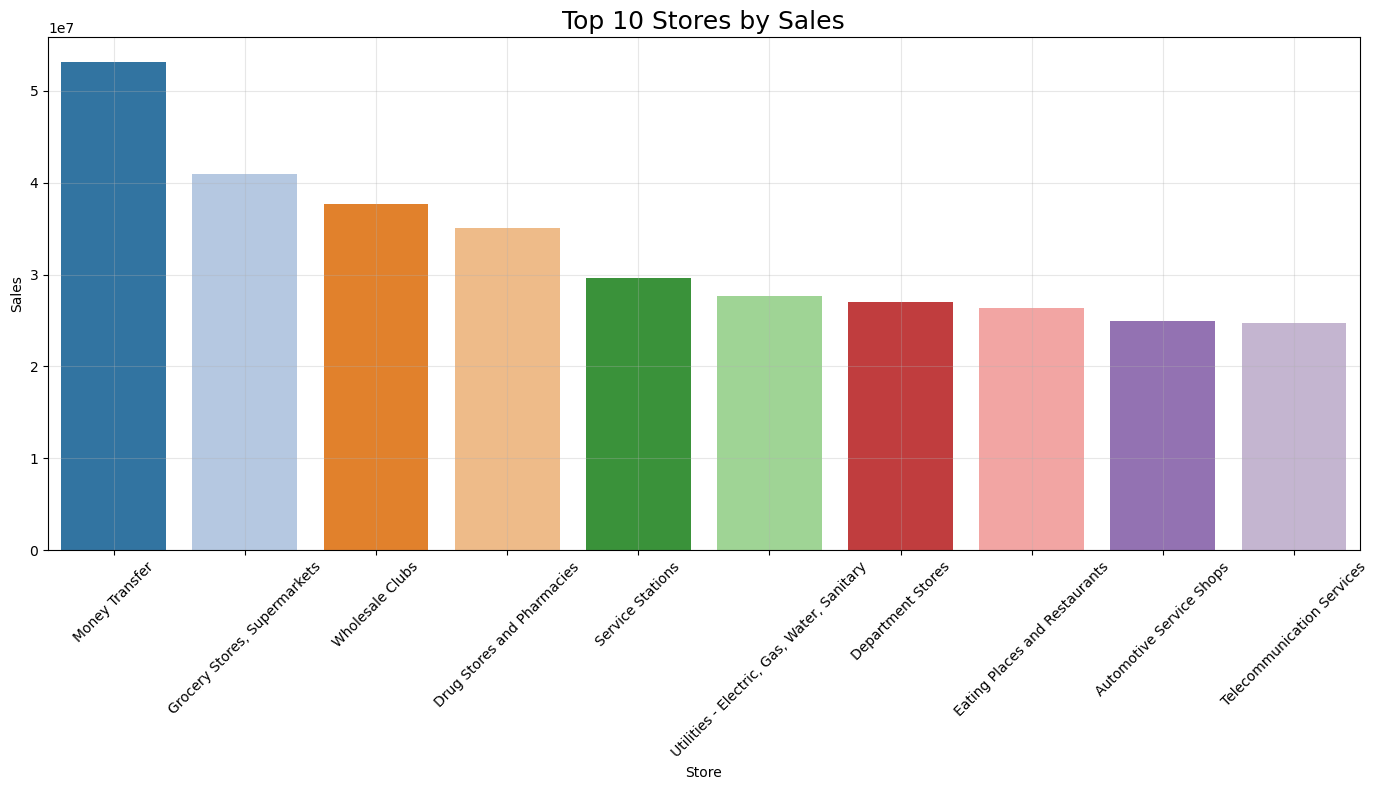

In [15]:
import plotly.express as px
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.io as pio
from IPython.display import IFrame

plt.figure(figsize=(14,8))
topStores = (
    df.groupby('Stores')['amount']
   .sum()
      .reset_index()
      .sort_values(by='amount', ascending=False).head(10)
)

topStores
sns.barplot(
    y='amount',
    x='Stores',
    data=topStores,
    palette='tab20' 
)

plt.title('Top 10 Stores by Sales', fontsize=18)
plt.ylabel('Sales')
plt.xlabel('Store')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

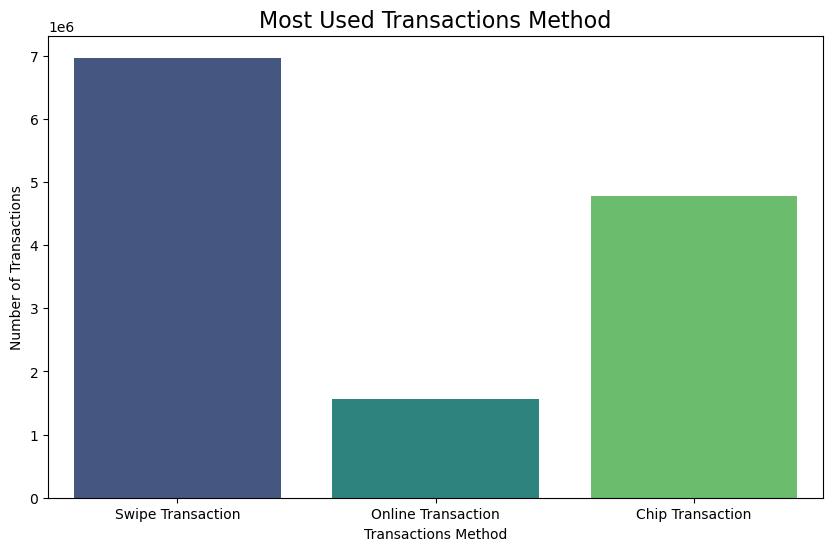

In [16]:
plt.figure(figsize=(10, 6))

sns.countplot(data=df, x='use_chip', palette='viridis')

plt.title('Most Used Transactions Method', fontsize=16)
plt.xlabel('Transactions Method')
plt.ylabel('Number of Transactions')
plt.show()

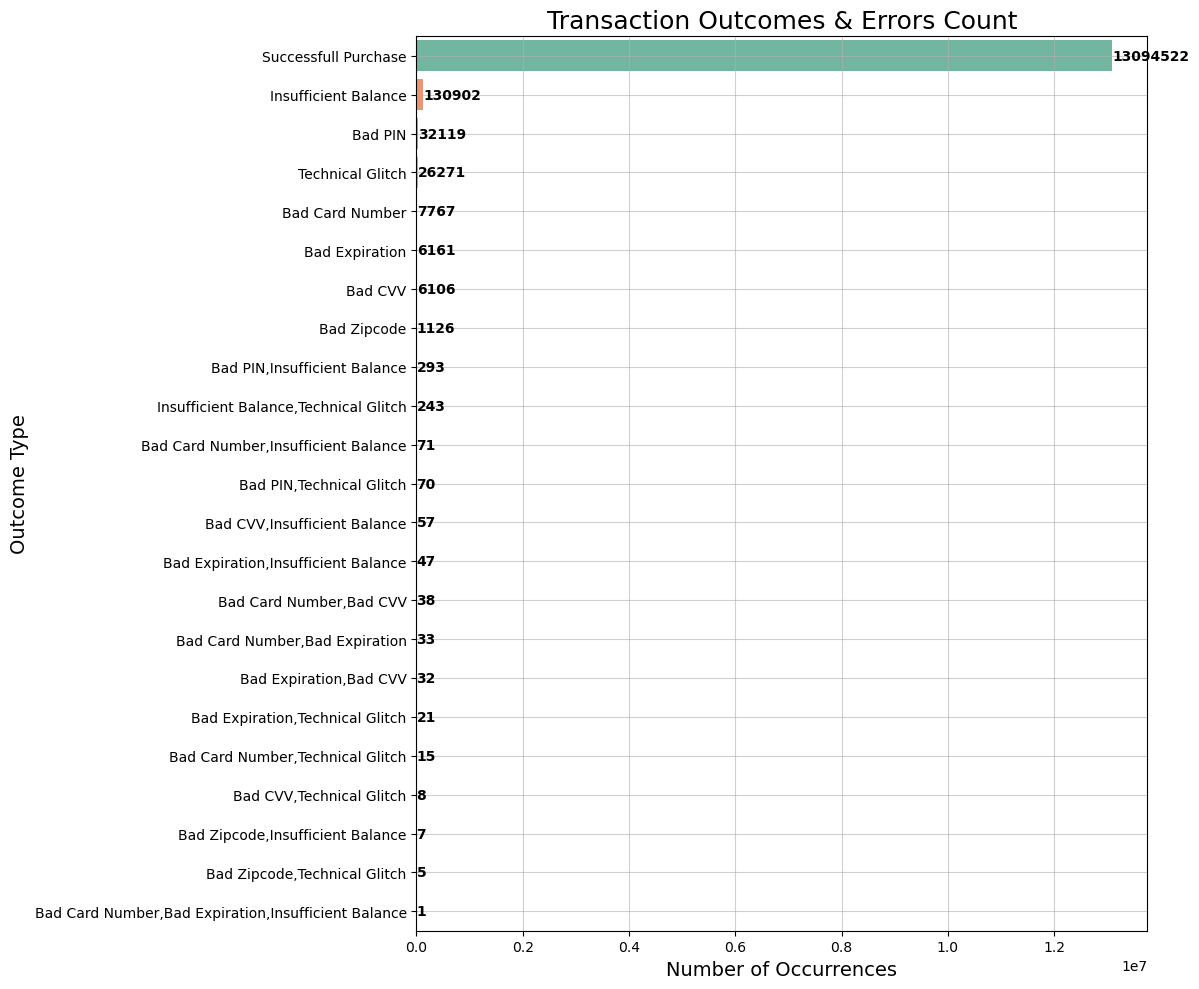

In [17]:

error_counts = df['errors'].value_counts()

plt.figure(figsize=(12, 10))

sns.barplot(
    x=error_counts.values, 
    y=error_counts.index, 
    palette='Set2'
)

plt.title('Transaction Outcomes & Errors Count', fontsize=18)
plt.xlabel('Number of Occurrences', fontsize=14)
plt.ylabel('Outcome Type', fontsize=14)
plt.grid(alpha=0.6)
for i, v in enumerate(error_counts.values):
    plt.text(v + 3, i, str(v), color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

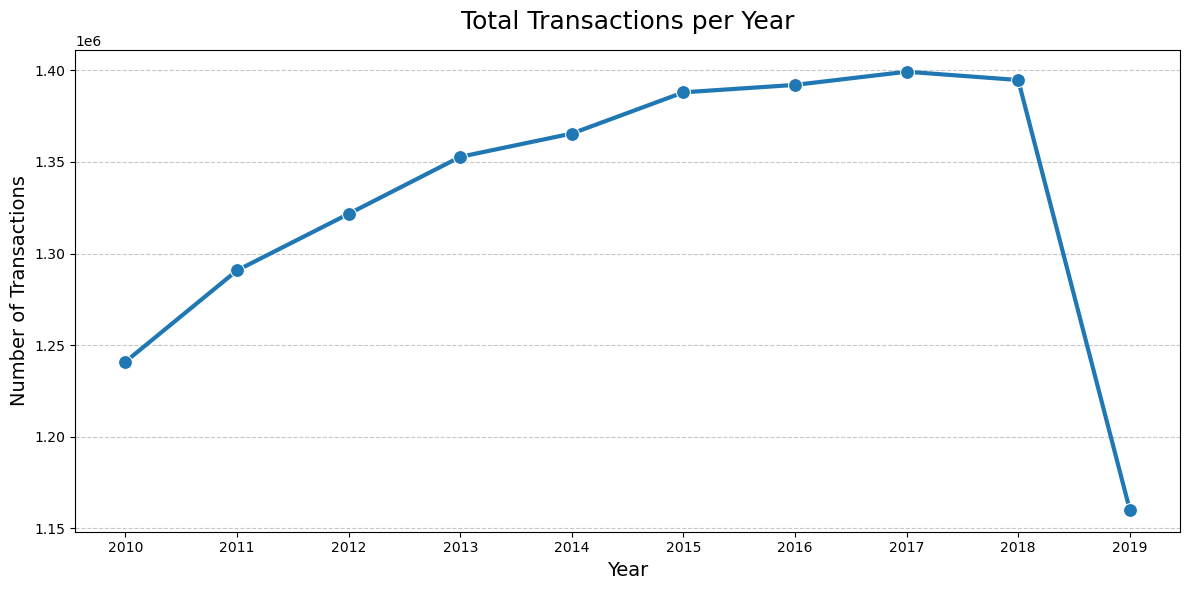

In [18]:

yearly_counts = df['date'].dt.year.value_counts().sort_index()

plt.figure(figsize=(12, 6))

sns.lineplot(
    x=yearly_counts.index, 
    y=yearly_counts.values, 
    marker='o',       
    markersize=10, 
    linewidth=3, 
    palette='tab20'
)

plt.title('Total Transactions per Year', fontsize=18, pad=15)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Number of Transactions', fontsize=14)

plt.xticks(yearly_counts.index) 

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

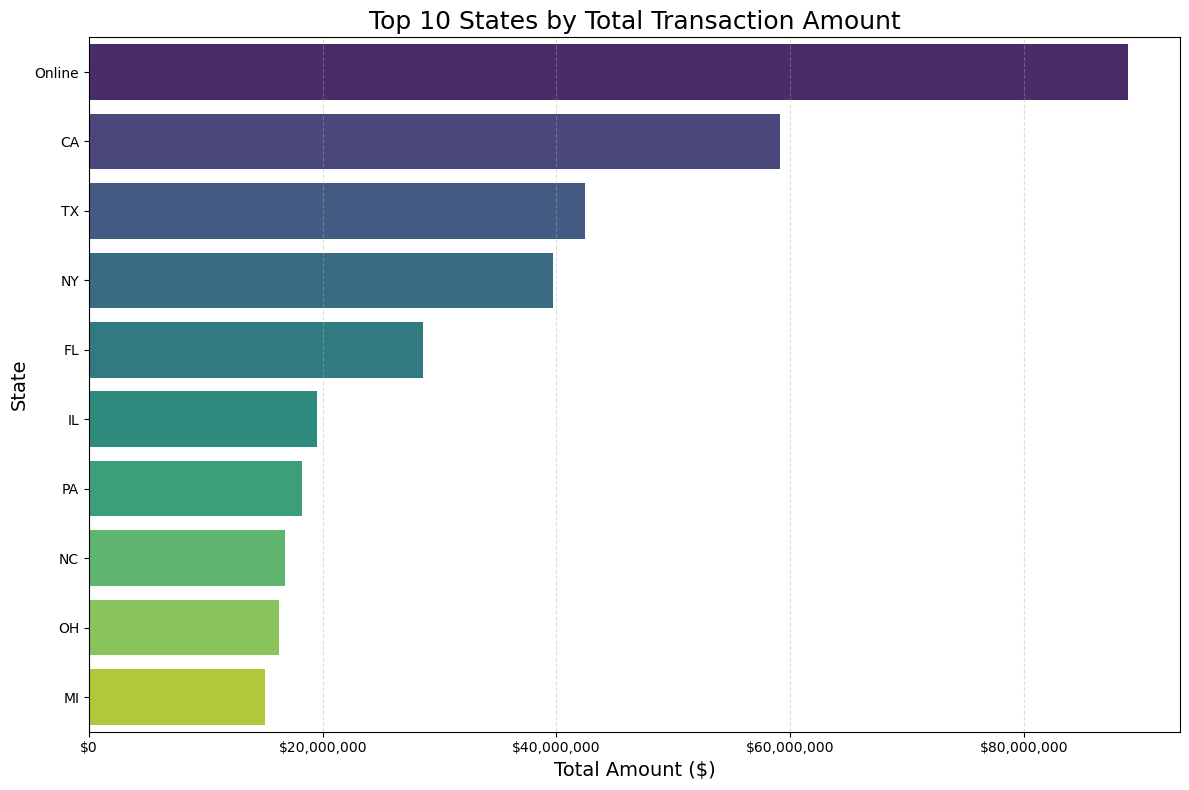

In [19]:

state_amounts = df.groupby('merchant_state')['amount'].sum().nlargest(10)

plt.figure(figsize=(12, 8))

sns.barplot(
    x=state_amounts.values, 
    y=state_amounts.index, 
    palette='viridis'
)

plt.title('Top 10 States by Total Transaction Amount', fontsize=18)
plt.xlabel('Total Amount ($)', fontsize=14)
plt.ylabel('State', fontsize=14)
from matplotlib.ticker import StrMethodFormatter
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

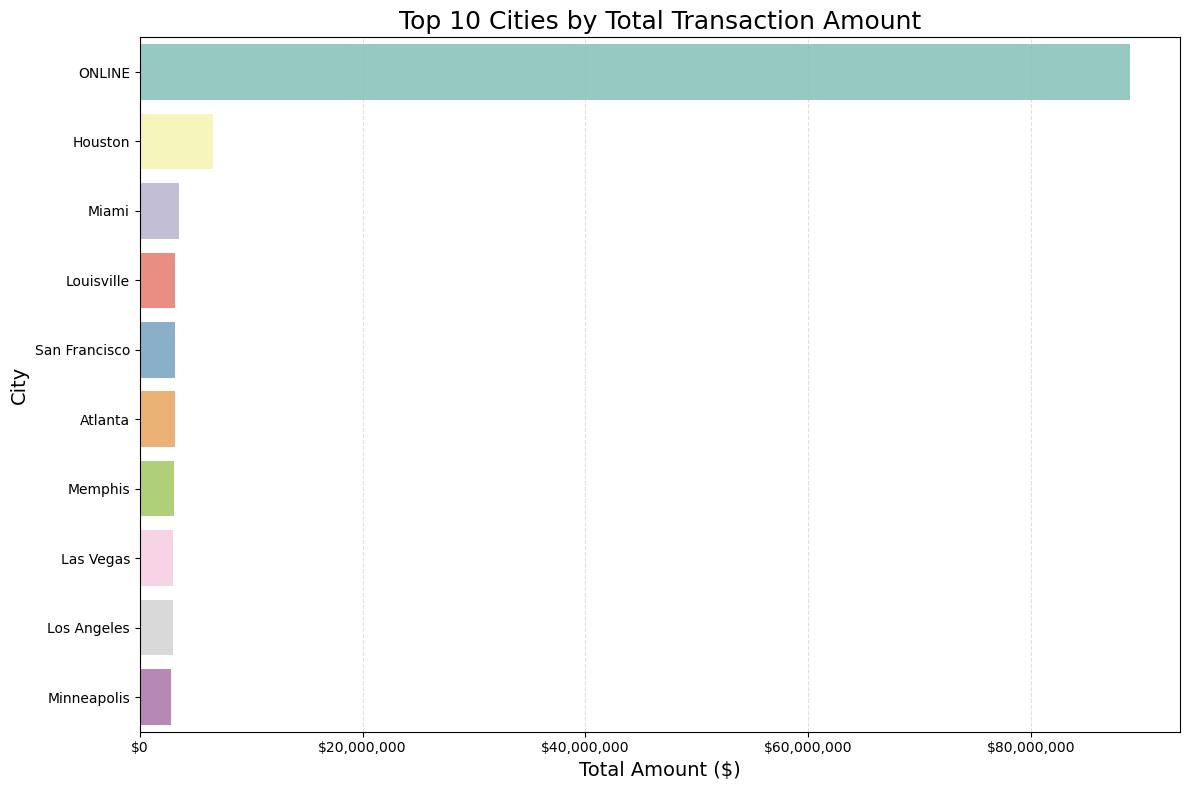

In [20]:

state_amounts = df.groupby('merchant_city')['amount'].sum().nlargest(10)

plt.figure(figsize=(12, 8))

sns.barplot(
    x=state_amounts.values, 
    y=state_amounts.index, 
    palette='Set3'
)

plt.title('Top 10 Cities by Total Transaction Amount', fontsize=18)
plt.xlabel('Total Amount ($)', fontsize=14)
plt.ylabel('City', fontsize=14)
from matplotlib.ticker import StrMethodFormatter
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Cards Data Analysis

In [21]:
df3=pd.read_csv(r"D:\Users\Iyyappa\Downloads\cards_data.csv")
df3

,id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web
0,4524,825,Visa,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
1,2731,825,Visa,Debit,4956965974959986,12/2020,393,YES,2,$21968,04/2014,2014,No
2,3701,825,Visa,Debit,4582313478255491,02/2024,719,YES,2,$46414,07/2003,2004,No
3,42,825,Visa,Credit,4879494103069057,08/2024,693,NO,1,$12400,01/2003,2012,No
4,4659,825,Mastercard,Debit (Prepaid),5722874738736011,03/2009,75,YES,1,$28,09/2008,2009,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6141,5361,185,Amex,Credit,300609782832003,01/2024,663,YES,1,$6900,11/2000,2013,No
6142,2711,185,Visa,Credit,4718517475996018,01/2021,492,YES,2,$5700,04/2012,2012,No
6143,1305,1007,Mastercard,Credit,5929512204765914,08/2020,237,NO,2,$9200,02/2012,2012,No
6144,743,1110,Mastercard,Debit,5589768928167462,01/2020,630,YES,1,$28074,01/2020,2020,No


In [22]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6146 entries, 0 to 6145
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     6146 non-null   int64 
 1   client_id              6146 non-null   int64 
 2   card_brand             6146 non-null   object
 3   card_type              6146 non-null   object
 4   card_number            6146 non-null   int64 
 5   expires                6146 non-null   object
 6   cvv                    6146 non-null   int64 
 7   has_chip               6146 non-null   object
 8   num_cards_issued       6146 non-null   int64 
 9   credit_limit           6146 non-null   object
 10  acct_open_date         6146 non-null   object
 11  year_pin_last_changed  6146 non-null   int64 
 12  card_on_dark_web       6146 non-null   object
dtypes: int64(6), object(7)
memory usage: 624.3+ KB


In [23]:
df3['expires']=pd.to_datetime(df3['expires'], errors='coerce')
df3['acct_open_date']=pd.to_datetime(df3['acct_open_date'], errors='coerce')
df3['credit_limit'] = (
 df3['credit_limit']
    .str.replace('[\$,]', '', regex=True)
)

df3['credit_limit'] = pd.to_numeric(df3['credit_limit'], errors='coerce')
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6146 entries, 0 to 6145
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     6146 non-null   int64         
 1   client_id              6146 non-null   int64         
 2   card_brand             6146 non-null   object        
 3   card_type              6146 non-null   object        
 4   card_number            6146 non-null   int64         
 5   expires                6146 non-null   datetime64[ns]
 6   cvv                    6146 non-null   int64         
 7   has_chip               6146 non-null   object        
 8   num_cards_issued       6146 non-null   int64         
 9   credit_limit           6146 non-null   int64         
 10  acct_open_date         6146 non-null   datetime64[ns]
 11  year_pin_last_changed  6146 non-null   int64         
 12  card_on_dark_web       6146 non-null   object        
dtypes: 

In [24]:
df3.head()

,id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web
0,4524,825,Visa,Debit,4344676511950444,2022-12-01,623,YES,2,24295,2002-09-01,2008,No
1,2731,825,Visa,Debit,4956965974959986,2020-12-01,393,YES,2,21968,2014-04-01,2014,No
2,3701,825,Visa,Debit,4582313478255491,2024-02-01,719,YES,2,46414,2003-07-01,2004,No
3,42,825,Visa,Credit,4879494103069057,2024-08-01,693,NO,1,12400,2003-01-01,2012,No
4,4659,825,Mastercard,Debit (Prepaid),5722874738736011,2009-03-01,75,YES,1,28,2008-09-01,2009,No


In [25]:
df3.tail()

,id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web
6141,5361,185,Amex,Credit,300609782832003,2024-01-01,663,YES,1,6900,2000-11-01,2013,No
6142,2711,185,Visa,Credit,4718517475996018,2021-01-01,492,YES,2,5700,2012-04-01,2012,No
6143,1305,1007,Mastercard,Credit,5929512204765914,2020-08-01,237,NO,2,9200,2012-02-01,2012,No
6144,743,1110,Mastercard,Debit,5589768928167462,2020-01-01,630,YES,1,28074,2020-01-01,2020,No
6145,3199,1110,Visa,Credit,4994011318343994,2020-12-01,120,YES,1,14400,2017-05-01,2017,No


In [26]:
df3.describe().T

,count,mean,min,25%,50%,75%,max,std
id,6146.0,3072.5,0.0,1536.25,3072.5,4608.75,6145.0,1774.341709
client_id,6146.0,994.939636,0.0,492.25,992.0,1495.0,1999.0,578.614626
card_number,6146.0,4820425803848956.0,300105541992311.0,4486365176018953.0,5108957434464472.0,5585237469514469.0,6997197066610978.0,1328582205754834.25
expires,6146,2020-10-08 06:30:06.443215360,1997-07-01 00:00:00,2020-02-01 00:00:00,2021-09-01 00:00:00,2023-05-01 00:00:00,2024-12-01 00:00:00,NaN
cvv,6146.0,506.220794,0.0,257.0,516.5,756.0,999.0,289.431123
num_cards_issued,6146.0,1.503091,1.0,1.0,1.0,2.0,3.0,0.519191
credit_limit,6146.0,14347.49398,0.0,7042.75,12592.5,19156.5,151223.0,12014.463884
acct_open_date,6146,2011-01-15 12:55:31.727953152,1991-01-01 00:00:00,2006-10-01 00:00:00,2010-02-15 00:00:00,2016-05-01 00:00:00,2020-02-01 00:00:00,NaN
year_pin_last_changed,6146.0,2013.436707,2002.0,2010.0,2013.0,2017.0,2020.0,4.270699


In [27]:
df3.isna().sum()

id                       0
client_id                0
card_brand               0
card_type                0
card_number              0
expires                  0
cvv                      0
has_chip                 0
num_cards_issued         0
credit_limit             0
acct_open_date           0
year_pin_last_changed    0
card_on_dark_web         0
dtype: int64

In [28]:
df3.columns

Index(['id', 'client_id', 'card_brand', 'card_type', 'card_number', 'expires',
       'cvv', 'has_chip', 'num_cards_issued', 'credit_limit', 'acct_open_date',
       'year_pin_last_changed', 'card_on_dark_web'],
      dtype='object')

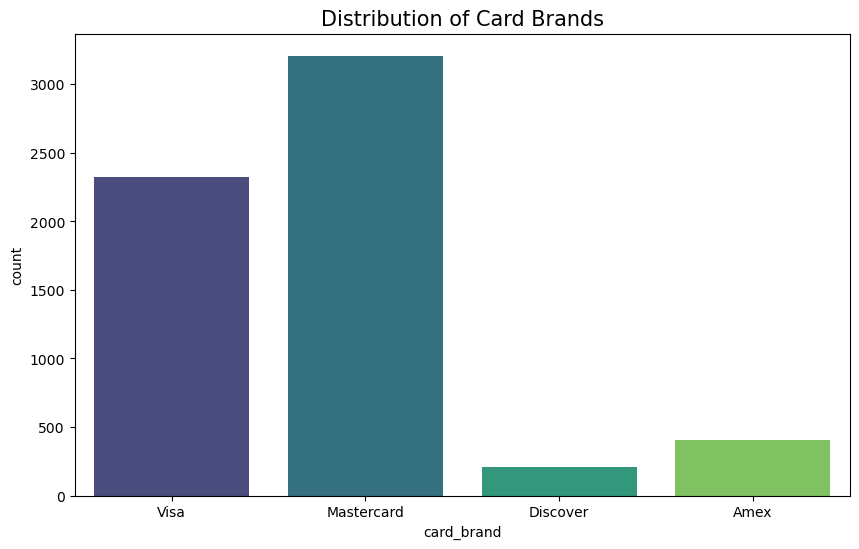

In [29]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df3, x='card_brand', palette='viridis')
plt.title('Distribution of Card Brands', fontsize=15)
plt.show()

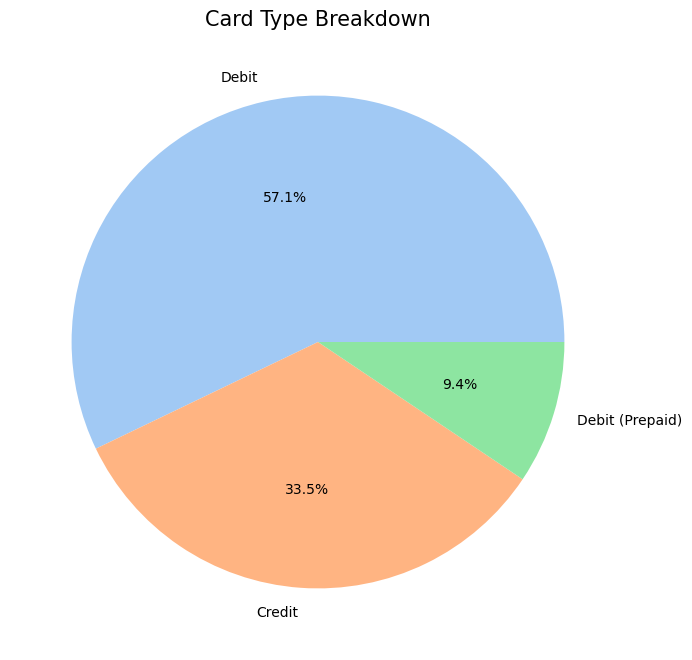

In [30]:
plt.figure(figsize=(8, 8))
type_counts = df3['card_type'].value_counts()
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Card Type Breakdown', fontsize=15)
plt.show()

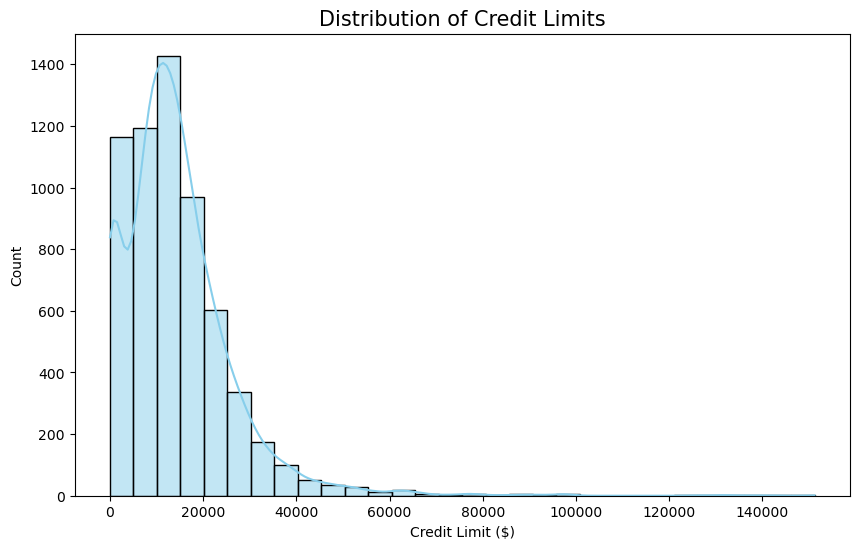

In [31]:
plt.figure(figsize=(10, 6))
sns.histplot(df3['credit_limit'], kde=True, color='skyblue', bins=30)
plt.title('Distribution of Credit Limits', fontsize=15)
plt.xlabel('Credit Limit ($)')
plt.show()

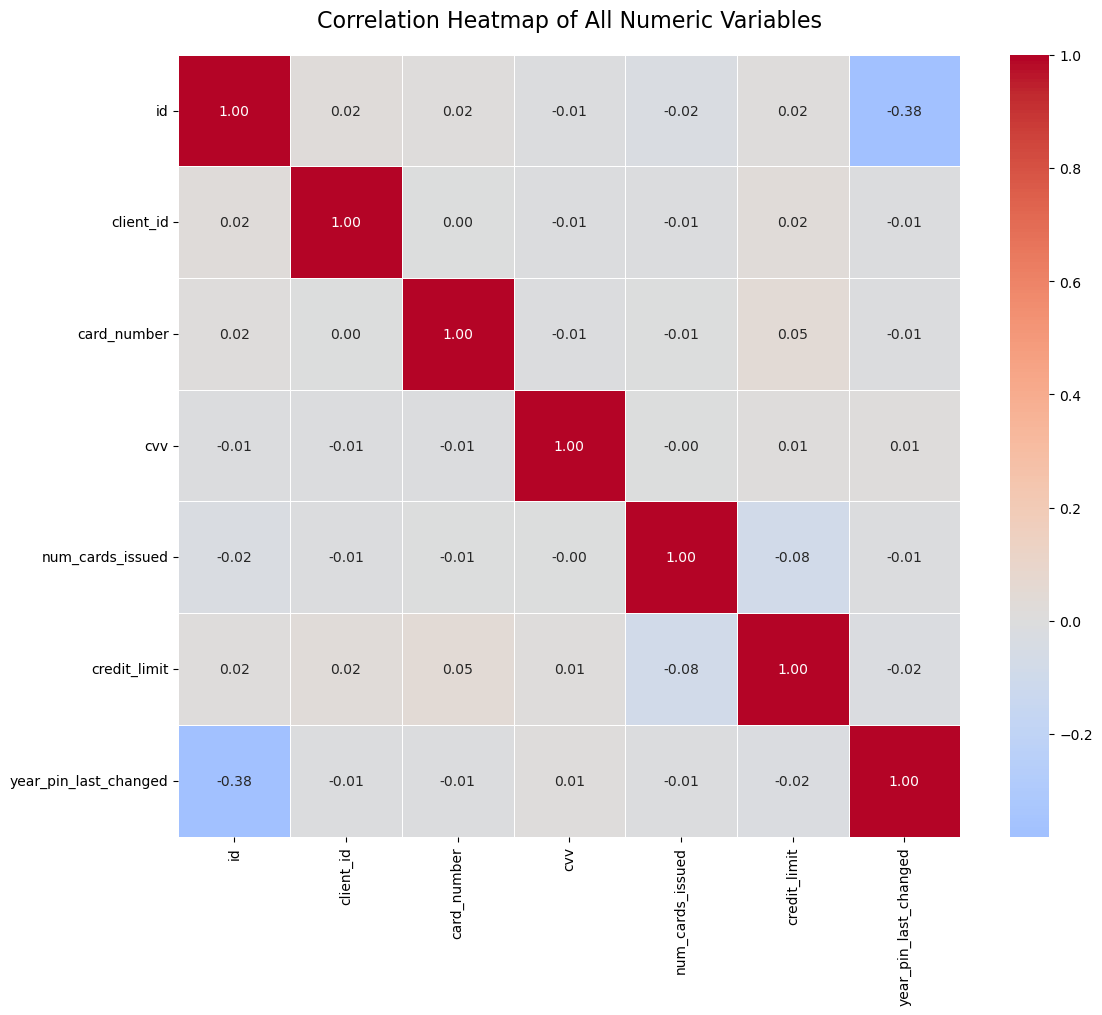

In [32]:

numeric_cols = df3.select_dtypes(include=['number', 'bool'])

corr_matrix = numeric_cols.corr()

plt.figure(figsize=(12, 10))


sns.heatmap(
    corr_matrix, 
    annot=True,         
    fmt=".2f",         
    cmap='coolwarm',     
    center=0,           
    linewidths=0.5,
    square=True         
)

plt.title('Correlation Heatmap of All Numeric Variables', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

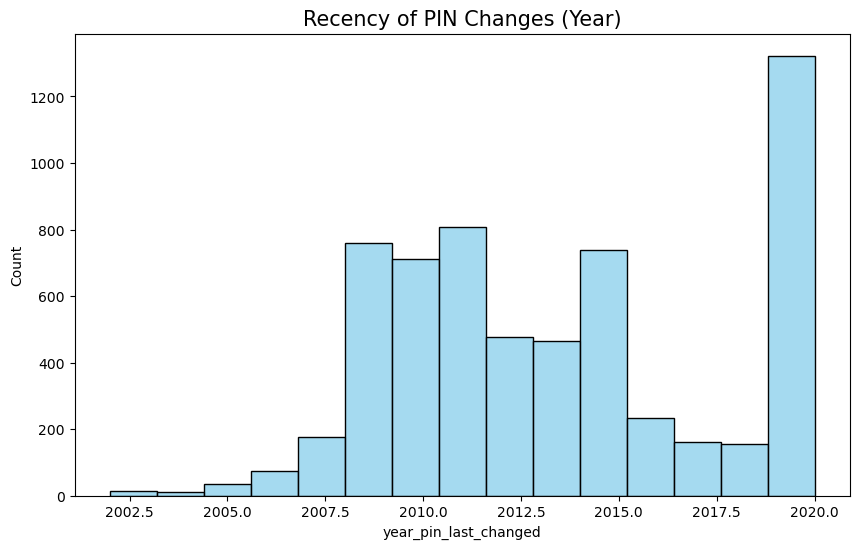

In [33]:
plt.figure(figsize=(10, 6))
sns.histplot(df3['year_pin_last_changed'], bins=15, color='skyblue')
plt.title('Recency of PIN Changes (Year)', fontsize=15)
plt.show()

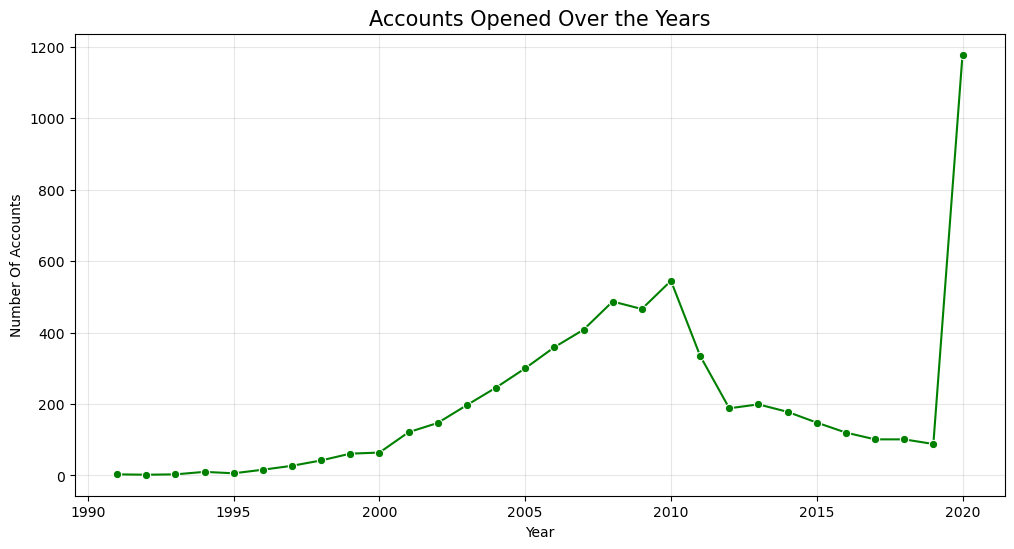

In [34]:
plt.figure(figsize=(12, 6))
df3['acct_open_date'] = pd.to_datetime(df3['acct_open_date'])
yearly_openings = df3['acct_open_date'].dt.year.value_counts().sort_index()
sns.lineplot(x=yearly_openings.index, y=yearly_openings.values, marker='o', color='green')
plt.title('Accounts Opened Over the Years', fontsize=15)
plt.xlabel('Year')
plt.ylabel('Number Of Accounts')
plt.grid(alpha=0.3)
plt.show()

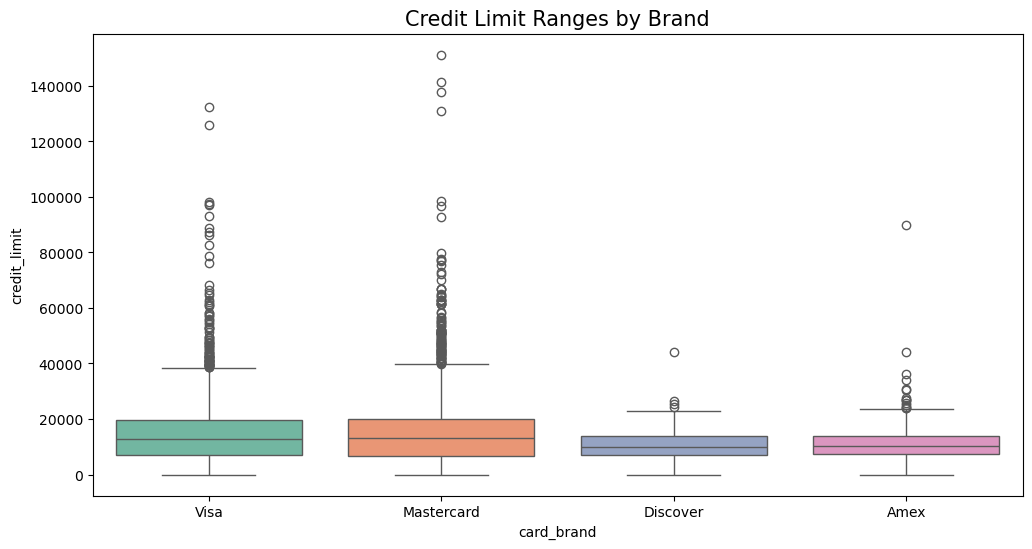

In [35]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df3, x='card_brand', y='credit_limit', palette='Set2')
plt.title('Credit Limit Ranges by Brand', fontsize=15)
plt.show()

# Users Data Analysis

In [36]:
df4=pd.read_csv(r"D:\Users\Iyyappa\Downloads\users_data.csv")
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 2000 non-null   int64  
 1   current_age        2000 non-null   int64  
 2   retirement_age     2000 non-null   int64  
 3   birth_year         2000 non-null   int64  
 4   birth_month        2000 non-null   int64  
 5   gender             2000 non-null   object 
 6   address            2000 non-null   object 
 7   latitude           2000 non-null   float64
 8   longitude          2000 non-null   float64
 9   per_capita_income  2000 non-null   object 
 10  yearly_income      2000 non-null   object 
 11  total_debt         2000 non-null   object 
 12  credit_score       2000 non-null   int64  
 13  num_credit_cards   2000 non-null   int64  
dtypes: float64(2), int64(7), object(5)
memory usage: 218.9+ KB


In [37]:
df4.head()

,id,current_age,retirement_age,birth_year,birth_month,gender,address,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
0,825,53,66,1966,11,Female,462 Rose Lane,34.15,-117.76,$29278,$59696,$127613,787,5
1,1746,53,68,1966,12,Female,3606 Federal Boulevard,40.76,-73.74,$37891,$77254,$191349,701,5
2,1718,81,67,1938,11,Female,766 Third Drive,34.02,-117.89,$22681,$33483,$196,698,5
3,708,63,63,1957,1,Female,3 Madison Street,40.71,-73.99,$163145,$249925,$202328,722,4
4,1164,43,70,1976,9,Male,9620 Valley Stream Drive,37.76,-122.44,$53797,$109687,$183855,675,1


In [38]:
df4.tail()

,id,current_age,retirement_age,birth_year,birth_month,gender,address,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
1995,986,32,70,1987,7,Male,6577 Lexington Lane,40.65,-73.58,$23550,$48010,$87837,703,3
1996,1944,62,65,1957,11,Female,2 Elm Drive,38.95,-84.54,$24218,$49378,$104480,740,4
1997,185,47,67,1973,1,Female,276 Fifth Boulevard,40.66,-74.19,$15175,$30942,$71066,779,3
1998,1007,66,60,1954,2,Male,259 Valley Boulevard,40.24,-76.92,$25336,$54654,$27241,618,1
1999,1110,21,60,1998,11,Female,472 Ocean View Street,42.86,-71.48,$32325,$65909,$181261,673,2


In [39]:

cols_to_fix = ['per_capita_income', 'yearly_income', 'total_debt']

for col in cols_to_fix:
   
    df4[col] = df4[col].astype(str).str.replace('[\$,]', '', regex=True)
    
  
    df4[col] = pd.to_numeric(df4[col], errors='coerce')

df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 2000 non-null   int64  
 1   current_age        2000 non-null   int64  
 2   retirement_age     2000 non-null   int64  
 3   birth_year         2000 non-null   int64  
 4   birth_month        2000 non-null   int64  
 5   gender             2000 non-null   object 
 6   address            2000 non-null   object 
 7   latitude           2000 non-null   float64
 8   longitude          2000 non-null   float64
 9   per_capita_income  2000 non-null   int64  
 10  yearly_income      2000 non-null   int64  
 11  total_debt         2000 non-null   int64  
 12  credit_score       2000 non-null   int64  
 13  num_credit_cards   2000 non-null   int64  
dtypes: float64(2), int64(10), object(2)
memory usage: 218.9+ KB


In [40]:
df4.isna().sum()

id                   0
current_age          0
retirement_age       0
birth_year           0
birth_month          0
gender               0
address              0
latitude             0
longitude            0
per_capita_income    0
yearly_income        0
total_debt           0
credit_score         0
num_credit_cards     0
dtype: int64

In [41]:
df4.columns

Index(['id', 'current_age', 'retirement_age', 'birth_year', 'birth_month',
       'gender', 'address', 'latitude', 'longitude', 'per_capita_income',
       'yearly_income', 'total_debt', 'credit_score', 'num_credit_cards'],
      dtype='object')

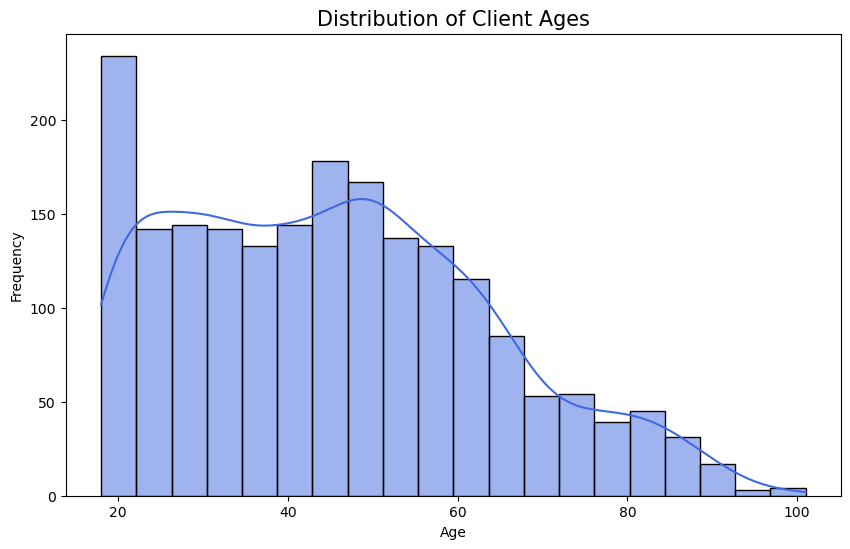

In [42]:
plt.figure(figsize=(10, 6))
sns.histplot(df4['current_age'], bins=20, kde=True, color='royalblue')
plt.title('Distribution of Client Ages', fontsize=15)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

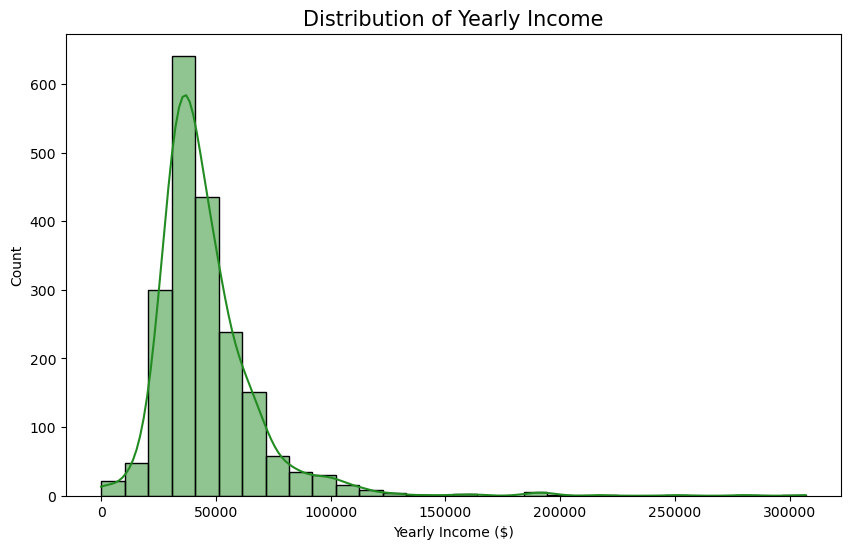

In [43]:
plt.figure(figsize=(10, 6))
sns.histplot(df4['yearly_income'], bins=30, kde=True, color='forestgreen')
plt.title('Distribution of Yearly Income', fontsize=15)
plt.xlabel('Yearly Income ($)')
plt.show()

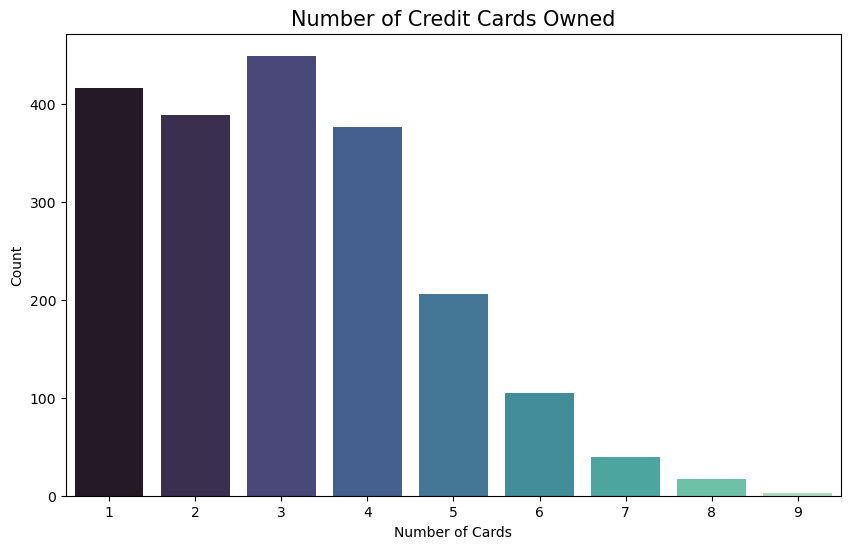

In [44]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df4, x='num_credit_cards', palette='mako')
plt.title('Number of Credit Cards Owned', fontsize=15)
plt.xlabel('Number of Cards')
plt.ylabel('Count')
plt.show()

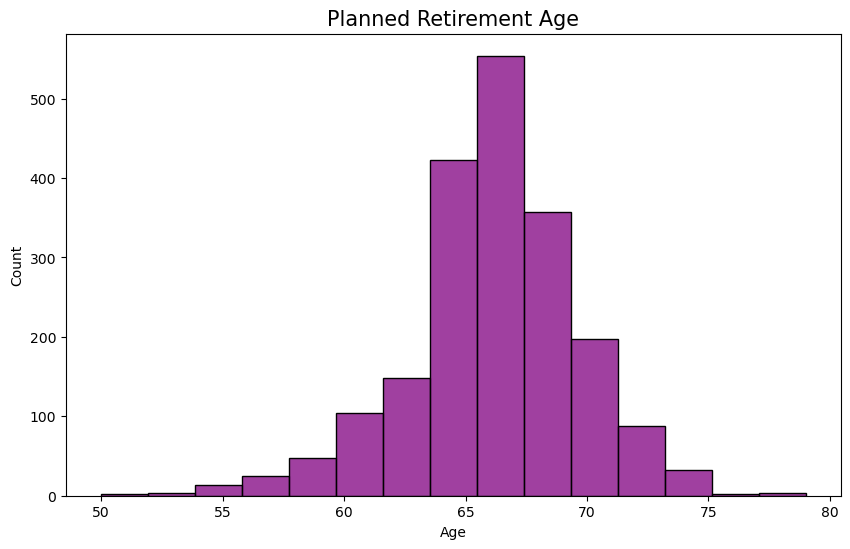

In [45]:
plt.figure(figsize=(10, 6))
sns.histplot(df4['retirement_age'], bins=15, color='purple')
plt.title('Planned Retirement Age', fontsize=15)
plt.xlabel('Age')
plt.show()

In [46]:
print("Thank you for reviewing this project.")

Thank you for reviewing this project.
